# Checker-Based Repair Beats Hygiene Retry Fixes

This notebook is a **demo version** of `method.py`, the script behind the experiment *"Checker-Based Repair Beats Hygiene Retry Fixes"*.

The full experiment scores three matched span-editing conditions on identical en→ru_RU / en→uk_UA machine-translation rows, using `google/gemma-3-12b-it` (OpenRouter) as the repair model:

- **B** — faithful reproduction of Padmanabhan (2025)'s masked-fill severity-skip baseline (QE-flagged spans masked with `__BLANK__`, single uncorrected LLM call).
- **D** — B plus a trivial *hygiene retry*: a second LLM call (temperature 0.3) fires only if leftover placeholder / leaked-instruction text is detected.
- **C1** — a from-scratch 4-category deterministic content-invariant *checker* (named entity via Stanza NER, number/unit/date via regex, negation polarity via per-language cue lists, quantifier scope via closed-class word lists) that flags every invariant span in the **full** sentence and repairs them all in one uncorrected pass.

**Headline finding**: condition B replicates Padmanabhan's direction/magnitude (pooled ΔCOMET −0.0164 vs the paper's −0.0108). Condition D (hygiene retry) barely moves ΔCOMET (−0.0157) — the hygiene retry essentially never fires usefully. Condition C1 (checker-broadened localization) cuts the COMET degradation roughly 5x versus B/D (−0.0035), at the cost of a lower fix-rate and a higher true-regression-rate on the injected-error subset.

**What this demo does** (with *minimal changes* to the original code — the same functions, split into cells with explanations):

The full pipeline makes ~1,447 paid LLM calls and loads a gated GPU COMET checkpoint, which is not practical to re-run in a demo. Instead, this notebook works on a curated subset (`mini_demo_data.json`) of the **actual, already-computed** experiment outputs (real LLM repairs from `method_out.json`, real headline metrics) and re-runs the parts of `method.py` that ARE cheap and deterministic:

1. The **4-category checker** (`checker.py`) — run for real on sample rows (its `named_entity`/Stanza category is included verbatim for fidelity, but is excluded from this experiment's scope for both languages -- see the checker validation results below).
2. The **edit-volume / leakage-detection** helper functions — recomputed from the real pre/post-repair texts and cross-checked against the stored values.
3. The **fix-rate / true-regression-rate aggregation** and **bootstrap CI** logic — run on the real per-row outcomes.
4. The **headline metrics** (ΔCOMET, fix-rate, etc.) from the real full run, for the final comparison plot.

## Setup
### Install dependencies
`numpy` and `matplotlib` ARE pre-installed on Colab, so they are only (re)installed locally, at Colab's exact pinned versions, to avoid corrupting Colab's pre-loaded C extensions. `stanza` (Stanford NLP's NER toolkit, used by the checker's `named_entity` category) is NOT pre-installed on Colab -- but it also pulls in `torch` as a hard dependency, which IS already present on Colab, so installing it here is deferred to the one detector that actually needs it (see `NamedEntityDetector._get_pipeline` below) rather than paid unconditionally up front.

In [1]:
import subprocess, sys

def _pip(*a):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *a])

# numpy, matplotlib -- pre-installed on Colab; install locally only, at Colab's exact versions
if "google.colab" not in sys.modules:
    _pip("numpy==2.0.2", "matplotlib==3.10.0")


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


### Imports
The original script's import block (`checker.py` + `method.py`), plus `matplotlib` for the results visualization at the end.

In [2]:
from __future__ import annotations

import json
import random
import re
from collections import Counter, defaultdict
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

### Data loading
`mini_demo_data.json` is a curated 80-row subset (40 natural rows, 40 injected-error rows -- 5 per language x category cell) of the real experiment output (`method_out.json`): real source text, real `google/gemma-3-12b-it` repairs for conditions B/D/C1, and the real per-row outcome flags (fix / regression / leakage / edit volume) that `method.py` computed. `metadata` also carries the real headline metrics (ΔCOMET, pooled fix-rate, checker validation, cost ledger, ...) from the full 320+240-row run.

Tries the GitHub raw URL first (works once this artifact is pushed / on Colab), falls back to the local file (works right now).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-e9bf19-isolating-what-fixes-failed-span-editing/main/round-2/experiment-3/demo/mini_demo_data.json"
import os


def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
natural_rows = data["datasets"][0]["examples"]
injected_rows = data["datasets"][1]["examples"]
print(f"Loaded {len(natural_rows)} natural rows and {len(injected_rows)} injected-error rows.")
print("Language pairs:", data["metadata"]["language_pairs"])
print("Repair model:", data["metadata"]["repair_model"])

Loaded 40 natural rows and 40 injected-error rows.
Language pairs: ['en-ru_RU', 'en-uk_UA']
Repair model: google/gemma-3-12b-it


## Config
Every tunable parameter used below, set to the smallest values that still produce a meaningful demo. `N_NATURAL_DEMO` / `N_INJECTED_DEMO` subselect from the already-small `mini_demo_data.json` (set to its full size by default -- raise the `min(...)` cap, or just point `DATA_PATH`-style loading at `full_method_out.json`, to scale back up toward the original 320/240-row run). `BOOTSTRAP_ITERS` is the original script's 1000-iteration bootstrap, reduced here for demo speed (original value commented alongside).

In [5]:
SEED = 42  # matches method.py's SEED
LANG_KEY_OF_PAIR = {"en-ru_RU": "ru_RU", "en-uk_UA": "uk_UA"}

N_NATURAL_DEMO = len(natural_rows)     # original run: 320 (160/pair). mini_demo_data.json ships 40 (20/pair); point the loader at full_method_out.json's dataset to go further.
N_INJECTED_DEMO = len(injected_rows)   # original run: 240 (30/cell). mini_demo_data.json ships 40 (5/cell).

BOOTSTRAP_ITERS = 1000  # original method.py value: 1000 -- cheap enough at this scale to use as-is.

HYGIENE_REGEX = re.compile(
    r"__BLANK__|__[A-Z]+__|\bCorrected words\b|\bHere is the corrected\b|\bHere's the corrected\b",
    re.IGNORECASE,
)

rng = random.Random(SEED)
demo_natural = rng.sample(natural_rows, N_NATURAL_DEMO)
demo_injected = rng.sample(injected_rows, N_INJECTED_DEMO)
print(f"Demo subset: {len(demo_natural)} natural rows, {len(demo_injected)} injected rows.")

Demo subset: 40 natural rows, 40 injected rows.


## The 4-category checker (`checker.py`)

This is condition C1's core novelty over B/D: a deterministic, content-invariant checker that localizes spans an LLM repair call should double-check against the source sentence, across four categories:

- `named_entity` — Stanza NER over the hypothesis text.
- `number_unit_date` — script-independent regex over digit sequences (+ optional attached unit token).
- `negation_polarity` — per-language cue-word list, applied per sentence, plus a source-alignment deletion signal for the case where the target-language negation marker was removed entirely.
- `quantifier_scope` — closed-class quantifier word lists per language.

The code below is copied essentially verbatim from `checker.py` (only the module-level docstring is trimmed for length).

In [6]:
CATEGORIES = (
    "named_entity",
    "number_unit_date",
    "negation_polarity",
    "quantifier_scope",
)

SUPPORTED_LANGS = ("ru_RU", "uk_UA")

# --- number/unit/date -------------------------------------------------------
# Script-independent digit-sequence regex + an optional attached unit/word
# token (letters immediately following, any script). Boundary guard: a digit
# run immediately preceded by '@' (handle-like token, e.g. @user12) is
# excluded.
_NUMBER_RE = re.compile(
    r"(?<![@\w])\d+(?:[.,]\d+)*\s?[A-Za-zА-яёіїєҐґ]{0,15}\b"
)

# --- negation cue lists -------------------------------------------------
NEGATION_CUES = {
    "ru_RU": [r"не", r"нет", r"ни"],
    "uk_UA": [r"не", r"ні", r"жодн\w*"],
}

# English negation cues, used only to decide whether an ALIGNED source
# sentence plausibly carries a negation the hypothesis sentence is missing
# (see detect_negation_polarity: the injected-data negation corruption is a
# DELETION of the target-language marker, so localizing it requires noticing
# an ABSENCE relative to source, not just matching a present cue word).
_EN_NEGATION_RE = re.compile(
    r"\bnot\b|n't\b|\bnever\b|\bno\b|\bnothing\b|\bnobody\b|\bnone\b|\bneither\b|\bnor\b|\bwithout\b",
    re.IGNORECASE,
)

# --- quantifier closed-class word lists ---------------------------------
QUANTIFIER_WORDS = {
    "ru_RU": [
        "все", "всех", "всем", "всеми", "весь", "вся", "всё",
        "каждый", "каждая", "каждое", "каждые", "каждого", "каждой",
        "некоторые", "некоторых", "многие", "многих", "мало",
        "несколько", "нескольких", "любой", "любая", "любое",
        "никто", "ничто", "никакой",
    ],
    "uk_UA": [
        "всі", "весь", "вся", "все", "усі", "увесь",
        "кожен", "кожна", "кожне", "кожні", "кожного", "кожної",
        "деякі", "деяких", "багато", "багатьох", "мало",
        "декілька", "кількох", "будь-який", "будь-яка", "будь-яке",
        "ніхто", "ніщо", "жоден",
    ],
}


@dataclass
class Span:
    start: int
    end: int
    text: str
    category: str


def _regex_spans(pattern: re.Pattern, text: str, category: str) -> list[Span]:
    return [Span(m.start(), m.end(), m.group(0), category) for m in pattern.finditer(text)]


def detect_number_unit_date(hyp_text: str) -> list[Span]:
    return _regex_spans(_NUMBER_RE, hyp_text, "number_unit_date")


_SENTENCE_SPLIT_RE = re.compile(r"[^.!?\n]*[.!?\n]|[^.!?\n]+$")


def _sentence_spans(text: str) -> list[tuple[int, int]]:
    """Char (start, end) offsets for each sentence-like chunk of text (split
    on .!?/newline, terminator kept with the preceding chunk)."""
    spans = []
    for m in _SENTENCE_SPLIT_RE.finditer(text):
        if m.group(0).strip():
            spans.append((m.start(), m.end()))
    return spans or [(0, len(text))]


def detect_negation_polarity(source_text: str, hyp_text: str, lang: str) -> list[Span]:
    """Per-language cue-word match, word-boundary, applied per SENTENCE (not
    the whole multi-sentence hypothesis document): a sentence fires when it
    contains EXACTLY ONE negation marker (Slavic/Czech negative-concord
    languages allow multiple co-occurring negation markers within a sentence,
    so removing just one does not reliably flip polarity unless it is the
    only one in that sentence). A second signal handles the DELETION case: a
    hyp sentence with ZERO negation cues whose position-aligned source
    sentence DOES contain an English negation cue is flagged as a suspected
    negation-deletion site."""
    cues = NEGATION_CUES[lang]
    combined = re.compile(r"\b(?:" + "|".join(cues) + r")\b", re.IGNORECASE)
    hyp_sents = _sentence_spans(hyp_text)
    src_sents = _sentence_spans(source_text) if source_text else []
    out: list[Span] = []
    for idx, (sent_start, sent_end) in enumerate(hyp_sents):
        sentence = hyp_text[sent_start:sent_end]
        matches = list(combined.finditer(sentence))
        if len(matches) == 1:
            m = matches[0]
            out.append(Span(sent_start + m.start(), sent_start + m.end(), m.group(0), "negation_polarity"))
        elif len(matches) == 0 and src_sents:
            src_idx = min(int(idx * len(src_sents) / max(1, len(hyp_sents))), len(src_sents) - 1)
            src_st, src_en = src_sents[src_idx]
            if _EN_NEGATION_RE.search(source_text[src_st:src_en]):
                out.append(Span(sent_start, sent_end, sentence, "negation_polarity"))
    return out


def detect_quantifier_scope(hyp_text: str, lang: str) -> list[Span]:
    words = sorted(QUANTIFIER_WORDS[lang], key=len, reverse=True)
    combined = re.compile(r"\b(?:" + "|".join(re.escape(w) for w in words) + r")\b", re.IGNORECASE)
    return _regex_spans(combined, hyp_text, "quantifier_scope")


class NamedEntityDetector:
    """Wraps a per-language Stanza NER pipeline. Lazily initialized (Stanza
    pipeline construction loads model weights, so this is done once per
    language and reused for every row). `stanza` itself (and its `torch`
    dependency) is only pip-installed here, the first time a pipeline is
    actually requested -- see the install-cell note above."""

    def __init__(self):
        self._pipelines: dict[str, object] = {}

    def _get_pipeline(self, lang: str):
        if lang not in self._pipelines:
            try:
                import stanza
            except ImportError:
                _pip("stanza==1.14.0")
                import stanza

            stanza_lang = {"ru_RU": "ru", "uk_UA": "uk"}[lang]
            stanza.download(stanza_lang, processors="tokenize,ner", verbose=False)
            self._pipelines[lang] = stanza.Pipeline(
                lang=stanza_lang,
                processors="tokenize,ner",
                use_gpu=False,
                verbose=False,
                download_method=None,
            )
        return self._pipelines[lang]

    def detect(self, hyp_text: str, lang: str) -> list[Span]:
        nlp = self._get_pipeline(lang)
        doc = nlp(hyp_text)
        spans = []
        for ent in doc.ents:
            spans.append(Span(ent.start_char, ent.end_char, ent.text, "named_entity"))
        return spans


class Checker:
    """Runs the four category detectors, respecting an exclusion list of
    (lang, category) cells that failed Phase-1 validation."""

    def __init__(self, excluded_cells: set[tuple[str, str]] | None = None):
        self.excluded_cells = excluded_cells or set()
        self._ner = NamedEntityDetector()

    def detect_category(self, category: str, source_text: str, hyp_text: str, lang: str) -> list[Span]:
        if category == "named_entity":
            return self._ner.detect(hyp_text, lang)
        if category == "number_unit_date":
            return detect_number_unit_date(hyp_text)
        if category == "negation_polarity":
            return detect_negation_polarity(source_text, hyp_text, lang)
        if category == "quantifier_scope":
            return detect_quantifier_scope(hyp_text, lang)
        raise ValueError(f"Unknown category: {category}")

    def detect_all(self, source_text: str, hyp_text: str, lang: str, *, respect_exclusions: bool) -> list[Span]:
        spans: list[Span] = []
        for cat in CATEGORIES:
            if respect_exclusions and (lang, cat) in self.excluded_cells:
                continue
            spans.extend(self.detect_category(cat, source_text, hyp_text, lang))
        return spans

    def is_flagged(self, category: str, source_text: str, hyp_text: str, lang: str, start: int, end: int) -> bool:
        """True if any span from this category's detector overlaps [start, end)."""
        for s in self.detect_category(category, source_text, hyp_text, lang):
            if s.start < end and start < s.end:
                return True
        return False


# Excluded cells: the (lang, category) pairs whose checker validation (on the
# heldout fold, see method.py's Phase 1) fell below recall/precision >= 0.5,
# taken from the real run's checker_validation.json (embedded in the loaded metadata).
# Note that ('ru_RU', 'named_entity') and ('uk_UA', 'named_entity') are BOTH
# excluded, so the Stanza-backed NamedEntityDetector above is never actually
# invoked below (respect_exclusions=True skips it for both languages) -- shown
# here for completeness/fidelity to checker.py, matching the real experiment's
# scope, not because this demo needs Stanza NER to reproduce its numbers.
excluded_cells = {
    tuple(cell.split("|"))
    for cell in data["metadata"]["checker_validation"]["excluded_cells"]
}
print("Excluded (lang, category) cells (recall<0.5 or precision<0.5):", excluded_cells)
checker = Checker(excluded_cells=excluded_cells)

Excluded (lang, category) cells (recall<0.5 or precision<0.5): {('ru_RU', 'named_entity'), ('uk_UA', 'named_entity'), ('uk_UA', 'quantifier_scope')}


### Run the checker on real rows

Below, `checker.detect_all(...)` runs for real on the demo natural rows, using each row's real `output` (pre-repair hypothesis) text -- respecting the same `excluded_cells` the real experiment computed, which happens to exclude `named_entity` for both languages, so this call never touches Stanza. We cross-check the recomputed flag count/categories against `metadata_c1_n_flags` / `metadata_c1_flag_categories`, which `method.py` computed identically at experiment time on that same pre-repair text.

In [7]:
print(f"{'row_id':<32} {'lang':<6} {'n_flags (recomputed)':<22} {'n_flags (stored)':<18} {'categories'}")
for row in demo_natural:
    lang = LANG_KEY_OF_PAIR[row["metadata_language_pair"]]
    source, hyp = row["input"], row["output"]
    flags = checker.detect_all(source, hyp, lang, respect_exclusions=True)
    cats = sorted({f.category for f in flags})
    print(f"{row['metadata_row_id']:<32} {lang:<6} {len(flags):<22} {row['metadata_c1_n_flags']:<18} {cats}")

row_id                           lang   n_flags (recomputed)   n_flags (stored)   categories
wmt25_task3_natural:3873         ru_RU  4                      4                  ['negation_polarity', 'quantifier_scope']
wmt25_task3_natural:3977         ru_RU  1                      1                  ['negation_polarity']
wmt25_task3_natural:3716         ru_RU  6                      6                  ['negation_polarity', 'number_unit_date', 'quantifier_scope']
wmt25_task3_natural:3663         ru_RU  1                      1                  ['number_unit_date']
wmt25_task3_natural:3649         ru_RU  3                      3                  ['negation_polarity', 'quantifier_scope']
wmt25_task3_natural:3651         ru_RU  4                      4                  ['negation_polarity', 'number_unit_date']
wmt25_task3_natural:3024         ru_RU  1                      1                  ['negation_polarity']
wmt25_task3_natural:3600         ru_RU  1                      1                

## Repair-quality helper functions (`method.py`)

These are the small deterministic helpers `method.py` uses to score every repair, independent of which condition (B/D/C1) produced it: `has_leakage` (did the model leave a placeholder / instruction-following artifact behind?), `word_edit_distance` / `edit_volume` (how much of the sentence did the repair actually touch?). Copied verbatim.

In [8]:
def has_leakage(text: str) -> bool:
    return bool(HYGIENE_REGEX.search(text))


def word_edit_distance(a: str, b: str) -> int:
    aw, bw = a.split(), b.split()
    n, m = len(aw), len(bw)
    if n == 0:
        return m
    if m == 0:
        return n
    prev = list(range(m + 1))
    for i in range(1, n + 1):
        cur = [i] + [0] * m
        for j in range(1, m + 1):
            cost = 0 if aw[i - 1] == bw[j - 1] else 1
            cur[j] = min(prev[j] + 1, cur[j - 1] + 1, prev[j - 1] + cost)
        prev = cur
    return prev[m]


def edit_volume(original: str, edited: str) -> float:
    n = max(1, len(original.split()))
    return word_edit_distance(original, edited) / n

### Recompute edit volume / leakage on real (original, repaired) text pairs

We recompute these directly from the real `output` (original hypothesis) and `predict_b` / `predict_d` / `predict_c1` (real repair-model outputs), and compare against the `metadata_*_edit_volume` / `metadata_*_leakage` values `method.py` stored at experiment time.

In [9]:
print(f"{'row_id':<32} {'cond':<5} {'edit_vol (recomputed)':<24} {'edit_vol (stored)':<19} {'leakage (recomputed)':<22} {'leakage (stored)'}")
mismatches = 0
for row in demo_natural:
    original = row["output"]
    for cond in ["b", "d", "c1"]:
        repaired = row[f"predict_{cond}"]
        ev_recomputed = round(edit_volume(original, repaired), 4)
        ev_stored = row[f"metadata_{cond}_edit_volume"]
        leak_recomputed = has_leakage(repaired)
        leak_stored = row[f"metadata_{cond}_leakage"]
        if ev_recomputed != ev_stored or leak_recomputed != leak_stored:
            mismatches += 1
        print(f"{row['metadata_row_id']:<32} {cond.upper():<5} {ev_recomputed:<24} {ev_stored:<19} {leak_recomputed!s:<22} {leak_stored}")
print(f"\n{mismatches} mismatches out of {len(demo_natural) * 3} (recomputed) checks.")

row_id                           cond  edit_vol (recomputed)    edit_vol (stored)   leakage (recomputed)   leakage (stored)
wmt25_task3_natural:3873         B     0.0805                   0.0805              False                  False
wmt25_task3_natural:3873         D     0.0805                   0.0805              False                  False
wmt25_task3_natural:3873         C1    0.0345                   0.0345              False                  False
wmt25_task3_natural:3977         B     0.0233                   0.0233              False                  False
wmt25_task3_natural:3977         D     0.0233                   0.0233              False                  False
wmt25_task3_natural:3977         C1    0.0                      0.0                 False                  False
wmt25_task3_natural:3716         B     0.0329                   0.0329              False                  False
wmt25_task3_natural:3716         D     0.0329                   0.0329              F

wmt25_task3_natural:4010         D     0.5893                   0.5893              False                  False
wmt25_task3_natural:4010         C1    0.0                      0.0                 False                  False
wmt25_task3_natural:4639         B     0.0619                   0.0619              False                  False
wmt25_task3_natural:4639         D     0.0619                   0.0619              False                  False


wmt25_task3_natural:4639         C1    0.0                      0.0                 False                  False
wmt25_task3_natural:3096         B     0.29                     0.29                False                  False
wmt25_task3_natural:3096         D     0.29                     0.29                False                  False
wmt25_task3_natural:3096         C1    0.01                     0.01                False                  False
wmt25_task3_natural:3448         B     0.1351                   0.1351              False                  False
wmt25_task3_natural:3448         D     0.1081                   0.1081              False                  False
wmt25_task3_natural:3448         C1    0.0                      0.0                 False                  False
wmt25_task3_natural:3830         B     0.0417                   0.0417              False                  False
wmt25_task3_natural:3830         D     0.0417                   0.0417              False       

## Injected-error subset: fix rate / true regression rate

On the injected-error rows, `method.py` computes two per-row outcomes for each condition (already stored in `metadata_{b,d,c1}_fixed` / `metadata_{b,d,c1}_true_regression`, since recomputing them from scratch needs the pre-corruption clean reference text, which is not carried into this demo's data file):

- `fixed` = 1 if the exact corrupted-span string is no longer present in the repaired output.
- `true_regression` = 1 if the repair introduced NEW collateral loss of genuinely-correct invariants, beyond what the injected corruption itself already removed.

The aggregation below (mean of the stored per-row booleans, pooled and per language pair) is the same aggregation `summarize_conditions()` performs in `method.py`, adapted here to the flat per-row schema of `mini_demo_data.json`.

In [10]:
conditions = ["b", "d", "c1"]
demo_fix_stats = {}
for cond in conditions:
    fixed = [row[f"metadata_{cond}_fixed"] for row in demo_injected if row.get(f"metadata_{cond}_fixed") is not None]
    regressed = [row[f"metadata_{cond}_true_regression"] for row in demo_injected if row.get(f"metadata_{cond}_true_regression") is not None]
    demo_fix_stats[cond.upper()] = {
        "fix_rate": round(sum(fixed) / len(fixed), 4) if fixed else None,
        "true_regression_rate": round(sum(regressed) / len(regressed), 4) if regressed else None,
        "n_rows": len(fixed),
    }

print(f"Demo injected-error subset (n={len(demo_injected)} rows):")
for cond, stats in demo_fix_stats.items():
    print(f"  {cond}: fix_rate={stats['fix_rate']}  true_regression_rate={stats['true_regression_rate']}  (n={stats['n_rows']})")

Demo injected-error subset (n=40 rows):
  B: fix_rate=0.7  true_regression_rate=0.05  (n=40)
  D: fix_rate=0.7  true_regression_rate=0.05  (n=40)
  C1: fix_rate=0.425  true_regression_rate=0.125  (n=40)


## Bootstrap CI and the real headline metrics

`bootstrap_ci` (copied verbatim from `method.py`) is the resampling routine used to put a 95% CI around every ΔCOMET mean in the paper. Reference-free ΔCOMET scoring itself needs the gated `Unbabel/wmt22-cometkiwi-da` GPU checkpoint and a live LLM run over the full 320-row natural subsample, which is not practical to redo in this demo -- so below we (a) demonstrate `bootstrap_ci` for real on the demo subset's real edit-volume values, and (b) pull the real, already-computed pooled ΔCOMET / fix-rate / true-regression-rate headline metrics (with their own real bootstrap CIs, `BOOTSTRAP_ITERS=1000`) straight out of `data["metadata"]["metrics"]`, which is exactly what `method_out.json` contains from the full run.

In [11]:
def bootstrap_ci(values: list[float], iters: int, rng: random.Random) -> tuple[float, float, float]:
    if not values:
        return (0.0, 0.0, 0.0)
    n = len(values)
    mean = sum(values) / n
    boots = []
    for _ in range(iters):
        sample = [values[rng.randrange(n)] for _ in range(n)]
        boots.append(sum(sample) / n)
    boots.sort()
    lo = boots[int(0.025 * iters)]
    hi = boots[min(iters - 1, int(0.975 * iters))]
    return (mean, lo, hi)


# Demo use: bootstrap-CI the real recomputed edit-volume values for condition C1
# on the demo natural subset (a small-n illustration of the same routine used
# for ΔCOMET in the real run).
bootstrap_rng = random.Random(SEED)
c1_edit_volumes = [edit_volume(row["output"], row["predict_c1"]) for row in demo_natural]
ev_mean, ev_lo, ev_hi = bootstrap_ci(c1_edit_volumes, BOOTSTRAP_ITERS, bootstrap_rng)
print(f"C1 edit_volume on demo subset (n={len(c1_edit_volumes)}): mean={ev_mean:.4f}, 95% CI=[{ev_lo:.4f}, {ev_hi:.4f}]")

# Real headline metrics from the full 320+240-row run (method_out.json), unpacked here.
pooled = data["metadata"]["metrics"]["pooled"]
print("\nHeadline pooled metrics from the full run:")
print(f"{'cond':<5} {'delta_comet_mean':<18} {'95% CI':<28} {'fix_rate':<10} {'true_regression_rate'}")
for cond in ["B", "D", "C1"]:
    m = pooled[cond]
    ci = m["delta_comet_ci95"]
    print(f"{cond:<5} {m['delta_comet_mean']:<18.4f} [{ci[0]:.4f}, {ci[1]:.4f}]{'':<10} {m['fix_rate']:<10} {m['true_regression_rate']}")

C1 edit_volume on demo subset (n=40): mean=0.0179, 95% CI=[0.0117, 0.0246]

Headline pooled metrics from the full run:
cond  delta_comet_mean   95% CI                       fix_rate   true_regression_rate
B     -0.0164            [-0.0237, -0.0101]           0.7375     0.05
D     -0.0157            [-0.0226, -0.0097]           0.7375     0.05
C1    -0.0035            [-0.0071, -0.0008]           0.4542     0.125


## Results

Reproduces the paper's headline comparison: pooled ΔCOMET (with 95% bootstrap CI) on the natural subsample, and fix-rate / true-regression-rate on the injected-error subsample, for all three conditions -- from the real, full-run metrics -- plus the demo subset's own recomputed fix/regression rates for comparison (small-n, so noisier).

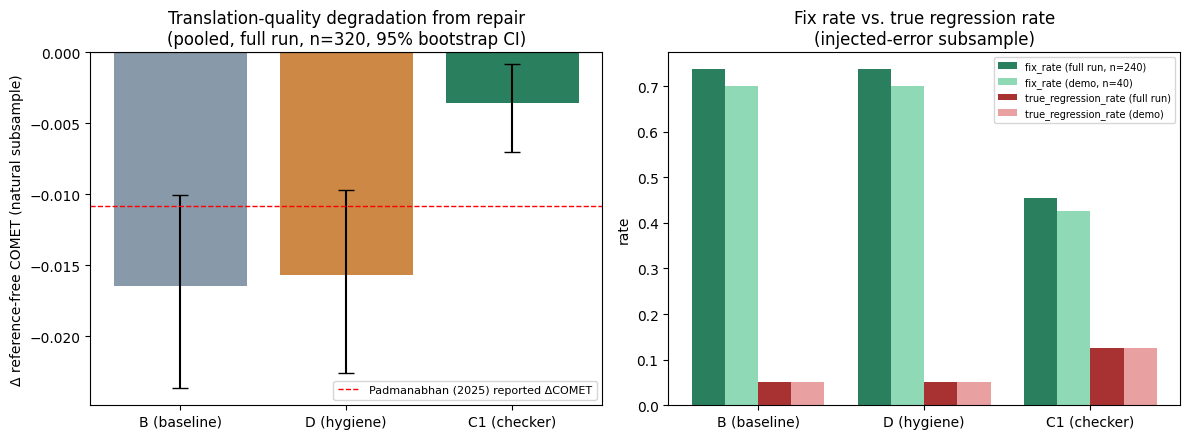


Summary table (full run, n=320 natural / 240 injected):
condition      delta_comet    95% CI                   fix_rate   true_regression_rate
B (baseline)   -0.0164        [-0.0237, -0.0101]         0.7375     0.05
D (hygiene)    -0.0157        [-0.0226, -0.0097]         0.7375     0.05
C1 (checker)   -0.0035        [-0.0071, -0.0008]         0.4542     0.125

Condition B leakage rate sanity check (masked rows): 0.0625
Reproduce verdict vs. Padmanabhan (2025): {'padmanabhan_reported_delta_comet': -0.0108, 'condition_B_pooled_delta_comet_mean': -0.016440192796289922, 'same_direction': True, 'magnitude_ratio_vs_paper': 1.5222400737305484}


In [12]:
cond_labels = ["B (baseline)", "D (hygiene)", "C1 (checker)"]
cond_keys = ["B", "D", "C1"]

delta_means = [pooled[c]["delta_comet_mean"] for c in cond_keys]
delta_los = [pooled[c]["delta_comet_ci95"][0] for c in cond_keys]
delta_his = [pooled[c]["delta_comet_ci95"][1] for c in cond_keys]
delta_errs = [
    [m - lo for m, lo in zip(delta_means, delta_los)],
    [hi - m for m, hi in zip(delta_means, delta_his)],
]

fix_rates = [pooled[c]["fix_rate"] for c in cond_keys]
regression_rates = [pooled[c]["true_regression_rate"] for c in cond_keys]
demo_fix_rates = [demo_fix_stats[c]["fix_rate"] or 0.0 for c in cond_keys]
demo_regression_rates = [demo_fix_stats[c]["true_regression_rate"] or 0.0 for c in cond_keys]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

colors = ["#8899aa", "#cc8844", "#2a7f5f"]

ax = axes[0]
ax.bar(cond_labels, delta_means, yerr=delta_errs, capsize=6, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(data["metadata"]["reproduce_verdict"]["padmanabhan_reported_delta_comet"], color="red",
           linestyle="--", linewidth=1, label="Padmanabhan (2025) reported ΔCOMET")
ax.set_ylabel("Δ reference-free COMET (natural subsample)")
ax.set_title("Translation-quality degradation from repair\n(pooled, full run, n=320, 95% bootstrap CI)")
ax.legend(fontsize=8)

ax = axes[1]
x = np.arange(len(cond_labels))
width = 0.2
ax.bar(x - 1.5 * width, fix_rates, width, label="fix_rate (full run, n=240)", color="#2a7f5f")
ax.bar(x - 0.5 * width, demo_fix_rates, width, label=f"fix_rate (demo, n={len(demo_injected)})", color="#8fd9b6")
ax.bar(x + 0.5 * width, regression_rates, width, label="true_regression_rate (full run)", color="#a83232")
ax.bar(x + 1.5 * width, demo_regression_rates, width, label="true_regression_rate (demo)", color="#e8a0a0")
ax.set_xticks(x)
ax.set_xticklabels(cond_labels)
ax.set_ylabel("rate")
ax.set_title("Fix rate vs. true regression rate\n(injected-error subsample)")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print("\nSummary table (full run, n=320 natural / 240 injected):")
print(f"{'condition':<14} {'delta_comet':<14} {'95% CI':<24} {'fix_rate':<10} {'true_regression_rate'}")
for label, c in zip(cond_labels, cond_keys):
    m = pooled[c]
    ci = m["delta_comet_ci95"]
    print(f"{label:<14} {m['delta_comet_mean']:<14.4f} [{ci[0]:.4f}, {ci[1]:.4f}]{'':<8} {m['fix_rate']:<10} {m['true_regression_rate']}")

print("\nCondition B leakage rate sanity check (masked rows):", data["metadata"]["condition_B_leakage_rate_sanity_check"])
print("Reproduce verdict vs. Padmanabhan (2025):", {
    k: data["metadata"]["reproduce_verdict"][k]
    for k in ["padmanabhan_reported_delta_comet", "condition_B_pooled_delta_comet_mean", "same_direction", "magnitude_ratio_vs_paper"]
})